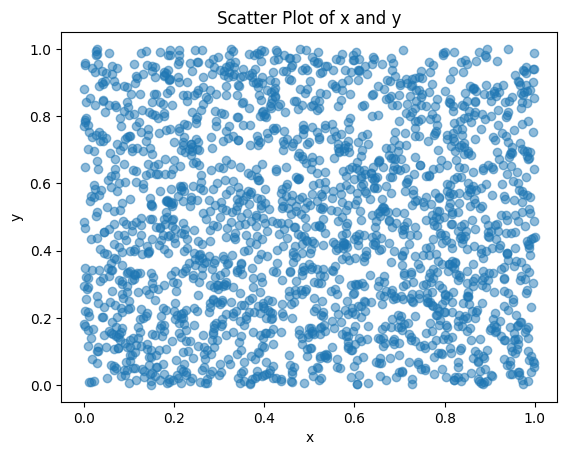

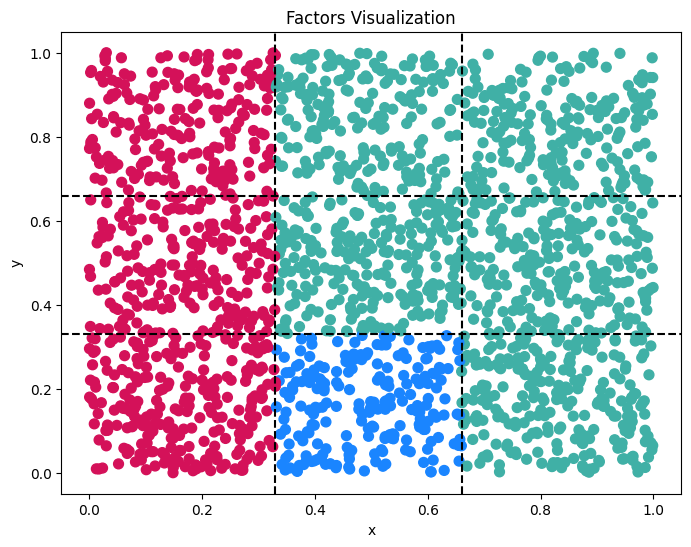

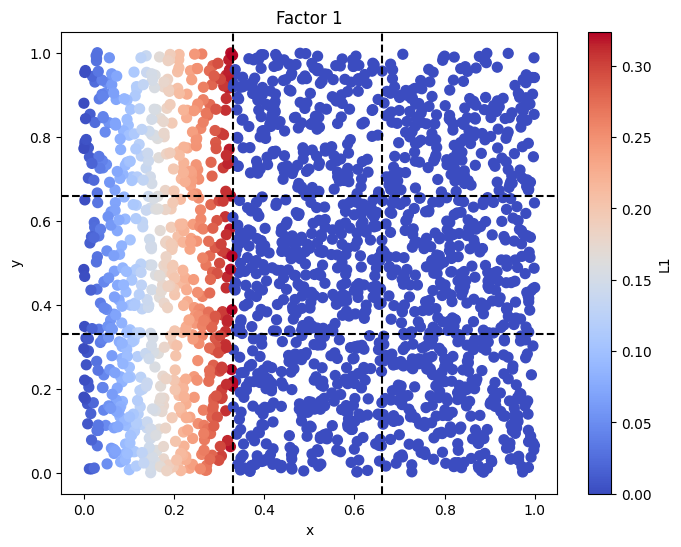

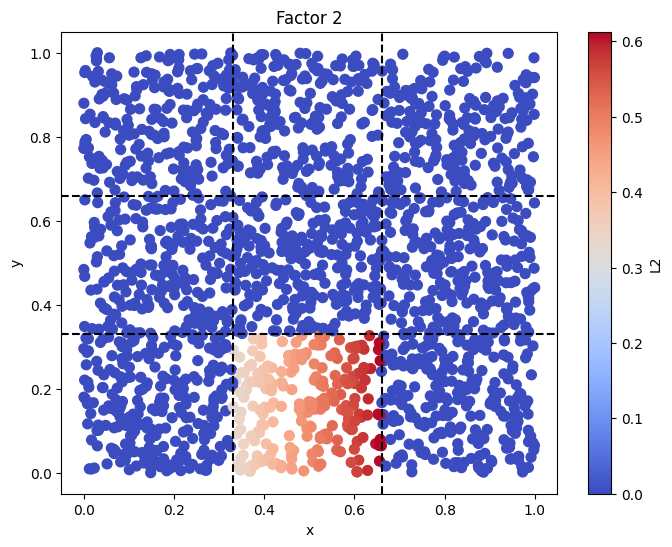

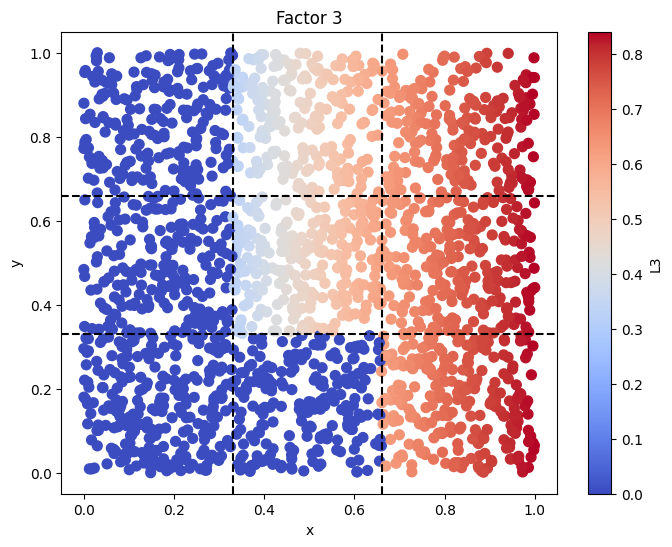

In [1]:
import torch
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(1)

# -------------------------
# 1) Random uniform data
# -------------------------
N = 2000
x = torch.rand(N)
y = torch.rand(N)
X = torch.stack([x, y], dim=1)  # (N,2)

# Scatter of x vs y
plt.scatter(x.numpy(), y.numpy(), alpha=0.5)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Scatter Plot of x and y")
plt.show()

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------
M = 200
t1 = torch.randint(0, 2, (M,), dtype=torch.float32)  # 0/1
t2 = torch.randint(0, 2, (M,), dtype=torch.float32)  # 0/1

f0 = t1 * torch.randn(M)
f1 = t2 * torch.randn(M)
f2 = t2 * torch.randn(M)
f  = torch.stack([f0, f1, f2], dim=0)  # (3, M)

# -------------------------
# 3) Build L (N x 3) and factor labels
# -------------------------
L = torch.zeros(N, 3, dtype=torch.float32)

mask1 = x < 0.33
mask2 = (~mask1) & (x < 0.66) & (y < 0.33)
mask3 = ~(mask1 | mask2)

L[mask1, 0] = torch.sin(x[mask1])
L[mask2, 1] = torch.sin(x[mask2])
L[mask3, 2] = torch.sin(x[mask3])

factor = torch.zeros(N, dtype=torch.long)
factor[mask1] = 1
factor[mask2] = 2
factor[mask3] = 3

# -------------------------
# 4) Factor visualization
# -------------------------
colors = ["#D41159", "#1A85FF", "#40B0A6"]
color_map = {1: colors[0], 2: colors[1], 3: colors[2]}
point_colors = [color_map[int(k)] for k in factor.tolist()]

plt.figure(figsize=(8,6))
plt.scatter(x.numpy(), y.numpy(), c=point_colors, s=50)
for v in [0.33, 0.66]:
    plt.axhline(v, color="black", linestyle="--")
    plt.axvline(v, color="black", linestyle="--")
plt.title("Factors Visualization")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# -------------------------
# 5) Individual factor plots (L1, L2, L3 as color)
# -------------------------
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()

# -------------------------
# 6) Generate Z = L @ f + noise
# -------------------------
Z = L @ f + torch.randn(N, M) #* 2.5  # (N, M)


In [2]:
from cebmf_torch import cEBMF

In [3]:
mycebmf=  cEBMF(data=Z ) 
mycebmf.initialise_factors()
mycebmf.fit(10)

CEBMFResult(L=tensor([[-6.7598e+00, -1.4332e-02,  1.8322e+00,  7.3666e-09, -1.6805e-07],
        [-1.2728e-01, -8.6281e-02,  2.0286e+00,  6.0323e-08, -6.9730e-08],
        [-1.6566e+00, -1.5823e-02, -1.1584e-02, -3.5545e-08, -4.5273e-07],
        ...,
        [-6.3495e+00, -9.7502e-01,  1.8474e-02, -1.5771e-08,  5.1932e-07],
        [-1.1016e-01,  6.2751e-02,  2.8442e+00,  7.0515e-08, -1.3537e-08],
        [-9.9256e-02,  1.2566e-01,  1.3082e+00, -2.2852e-08,  6.4646e-08]]), F=tensor([[-1.3574e-01,  1.4970e-01, -8.4925e-02,  1.7955e-20, -9.2379e-20],
        [ 1.6497e-01,  1.4324e-01,  3.9473e-04,  6.2239e-22, -4.8161e-20],
        [-5.1115e-04, -6.7892e-04,  5.7604e-02,  1.2625e-20, -2.6089e-19],
        [-5.5547e-02,  1.2525e-01,  6.6623e-02, -6.9378e-20,  2.1532e-20],
        [ 1.5923e-05, -2.8374e-02,  6.6553e-02, -1.1059e-19, -7.3227e-20],
        [ 1.1018e-03,  1.7563e-03, -4.5966e-04,  6.3003e-21,  1.4014e-20],
        [-1.2125e-05, -9.3930e-03, -5.1896e-04, -1.2304e-19, -1.7528e

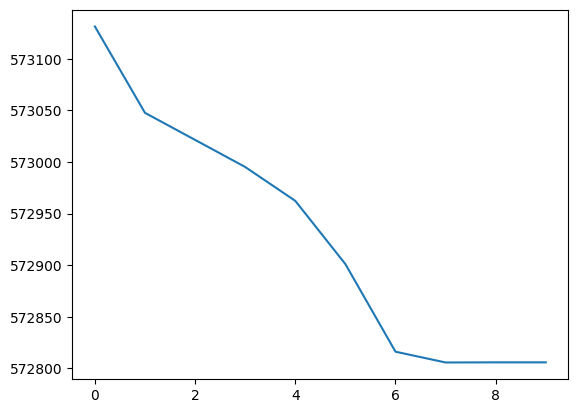

In [4]:
plt.plot(mycebmf.obj)
mycebmf._update_fitted_value()

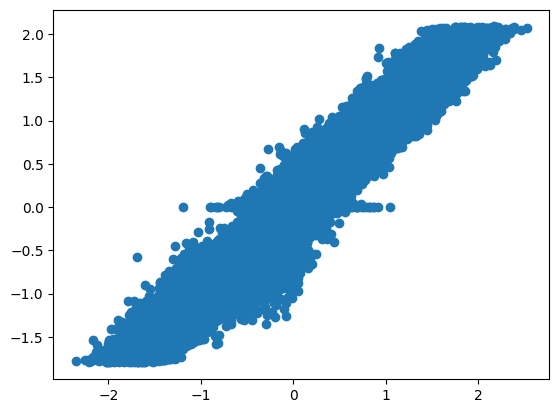

In [5]:
plt.scatter(mycebmf.Y_fit,L@f)

In [6]:
mycebmf1=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb" ) 
mycebmf1.initialise_factors()
mycebmf1.fit(10)

[CGB] Epoch 10/10, Loss=3.1073, mu2=-0.149, sigma2=6.592
[CGB] Epoch 10/10, Loss=1.7869, mu2=-0.100, sigma2=4.300
[CGB] Epoch 10/10, Loss=1.9241, mu2=0.116, sigma2=2.656
[CGB] Epoch 10/10, Loss=1.7681, mu2=-0.013, sigma2=2.232
[CGB] Epoch 10/10, Loss=1.7606, mu2=-0.009, sigma2=2.220
[CGB] Epoch 10/10, Loss=3.0580, mu2=-0.308, sigma2=6.467
[CGB] Epoch 10/10, Loss=1.6898, mu2=-0.250, sigma2=4.416
[CGB] Epoch 10/10, Loss=1.8163, mu2=0.266, sigma2=2.691
[CGB] Epoch 10/10, Loss=1.6283, mu2=-0.036, sigma2=3.416
[CGB] Epoch 10/10, Loss=1.6503, mu2=-0.016, sigma2=2.979
[CGB] Epoch 10/10, Loss=3.0291, mu2=-0.468, sigma2=6.311
[CGB] Epoch 10/10, Loss=1.6741, mu2=-0.404, sigma2=4.292
[CGB] Epoch 10/10, Loss=1.7815, mu2=0.421, sigma2=2.518
[CGB] Epoch 10/10, Loss=4.7921, mu2=-0.032, sigma2=0.001
[CGB] Epoch 10/10, Loss=2.9991, mu2=-0.627, sigma2=6.142
[CGB] Epoch 10/10, Loss=1.6592, mu2=-0.558, sigma2=4.139
[CGB] Epoch 10/10, Loss=1.7492, mu2=0.578, sigma2=2.329
[CGB] Epoch 10/10, Loss=2.9858, mu2

CEBMFResult(L=tensor([[-6.7301e+00,  0.0000e+00,  0.0000e+00],
        [-5.0244e-06,  0.0000e+00,  1.5296e+00],
        [-1.5195e+00,  0.0000e+00,  0.0000e+00],
        ...,
        [-6.3459e+00,  0.0000e+00,  0.0000e+00],
        [-8.8660e-07,  0.0000e+00,  1.6495e+00],
        [-1.4456e-08,  0.0000e+00,  1.3649e+00]]), F=tensor([[-1.3761e-01,  1.6822e-01, -1.6044e-01],
        [ 1.6867e-01,  1.6737e-01,  4.3655e-03],
        [-4.7133e-04, -1.0759e-03,  7.5154e-02],
        [-5.6501e-02,  1.3868e-01,  1.5802e-01],
        [ 1.1035e-05, -4.1436e-02,  1.2716e-01],
        [ 1.0260e-03,  2.9223e-03,  1.3289e-03],
        [-2.5421e-05, -1.2676e-02, -2.1096e-03],
        [-1.9580e-01,  1.6869e-01,  2.1750e-02],
        [-2.5537e-05, -8.3201e-05, -1.5858e-01],
        [-8.6423e-02,  2.7106e-01,  2.1221e-02],
        [-1.0541e-01,  6.7601e-02,  2.6896e-01],
        [ 9.9946e-02,  1.4520e-01,  7.1933e-03],
        [-2.2420e-04, -7.1573e-04, -2.3428e-01],
        [ 1.0027e-03,  1.1126e-03, -2.

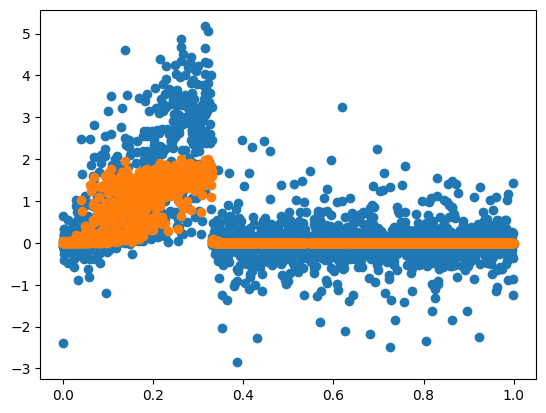

In [7]:
k=2
plt.scatter(x, mycebmf.L[:,k] )
plt.scatter( x,mycebmf1.L[:,k] )

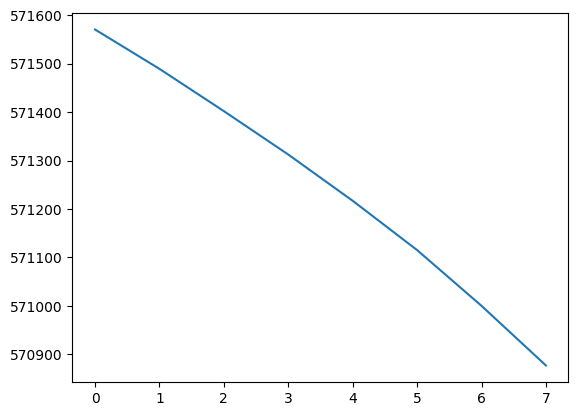

In [8]:
plt.plot(mycebmf1.obj)
mycebmf1._update_fitted_value()

tensor(0.0087)
tensor(0.0053)


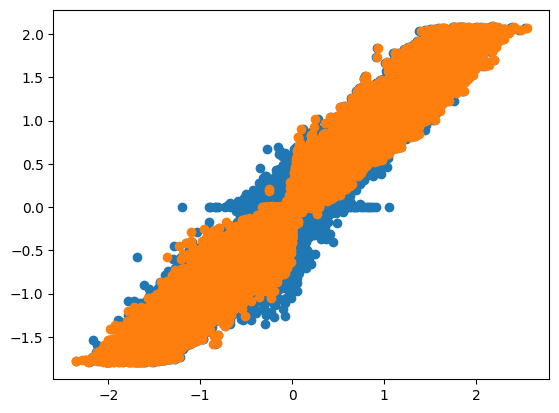

In [9]:
plt.scatter(mycebmf.Y_fit,L@f)
plt.scatter(mycebmf1.Y_fit,L@f)
print(torch.mean((mycebmf.Y_fit-L@f).pow(2)))

print(torch.mean((mycebmf1.Y_fit-L@f).pow(2)))

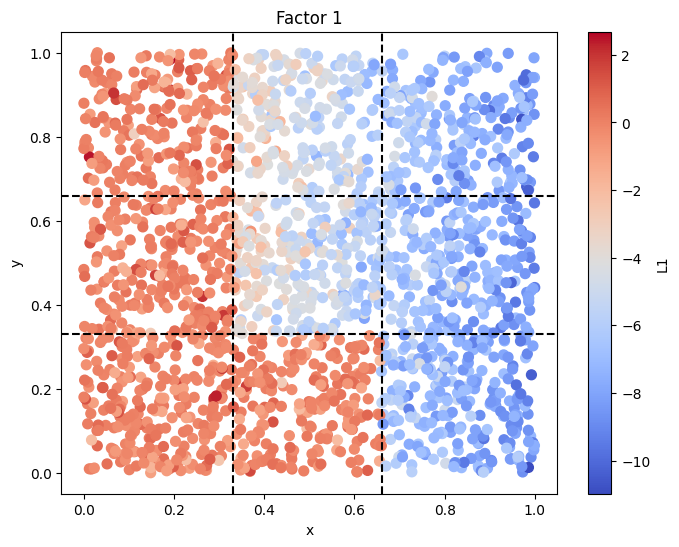

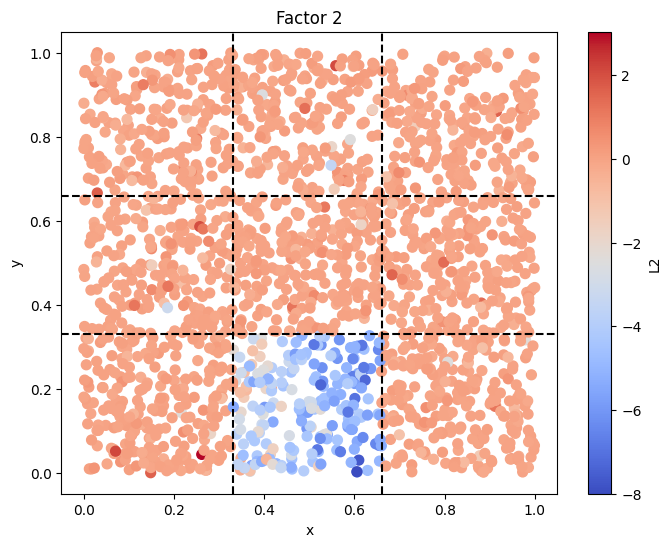

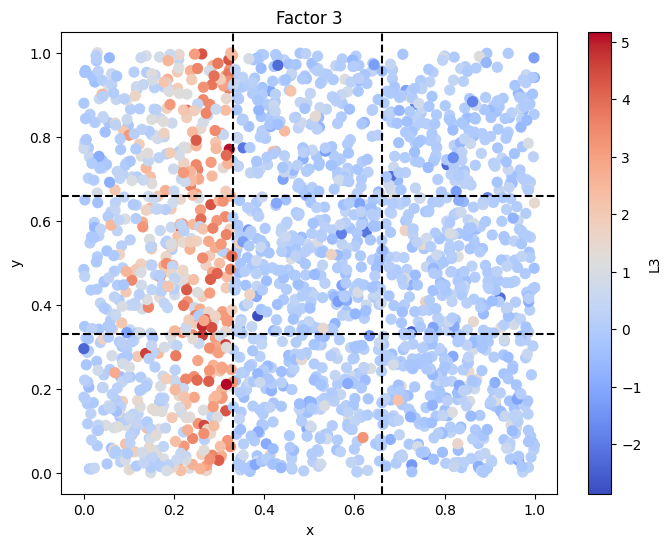

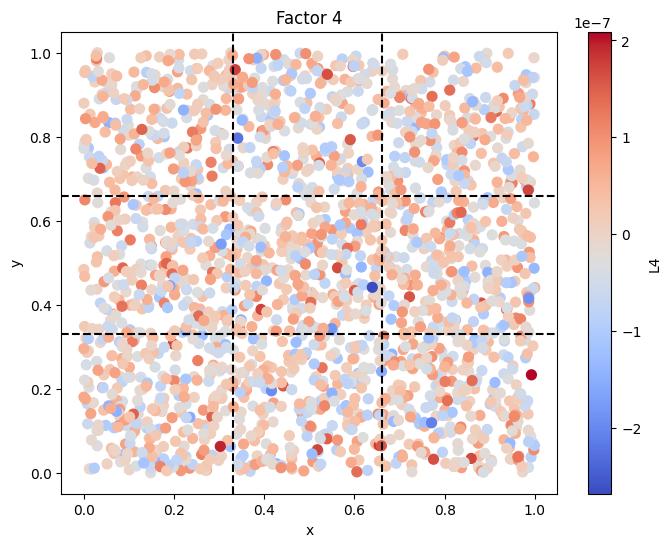

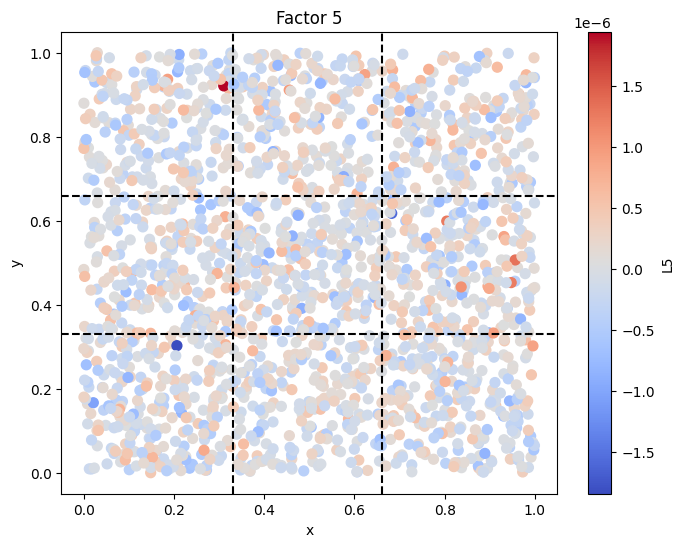

In [10]:
for i in range(5):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


In [11]:
mycebmf1.L

tensor([[-6.7301e+00,  0.0000e+00,  0.0000e+00],
        [-5.0244e-06,  0.0000e+00,  1.5296e+00],
        [-1.5195e+00,  0.0000e+00,  0.0000e+00],
        ...,
        [-6.3459e+00,  0.0000e+00,  0.0000e+00],
        [-8.8660e-07,  0.0000e+00,  1.6495e+00],
        [-1.4456e-08,  0.0000e+00,  1.3649e+00]])

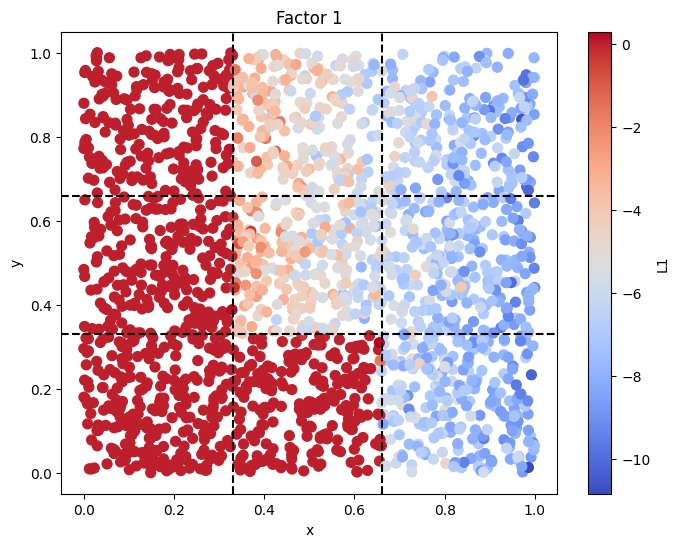

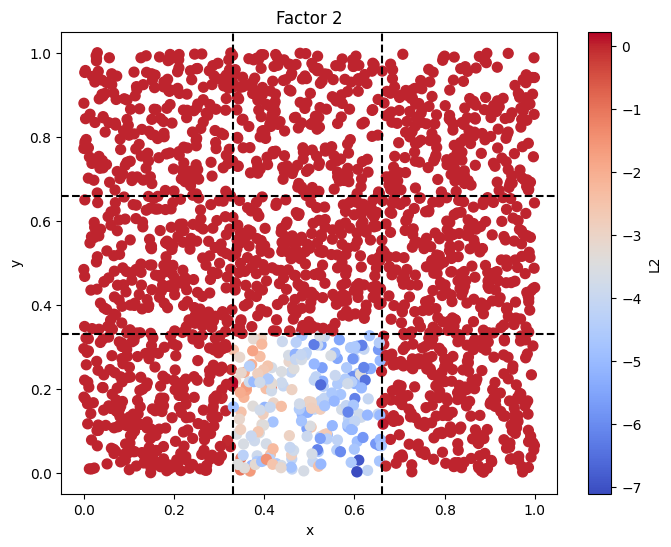

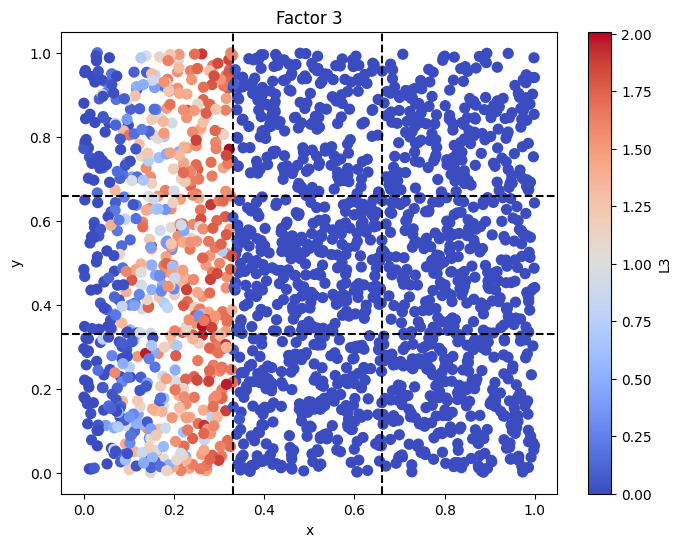

In [12]:
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf1.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()
